In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
path = "/content/drive/MyDrive/dataPackage/"

In [5]:
import pandas as pd

customers = pd.read_csv(path + "customers.csv")
orders = pd.read_csv(path + "orders.csv")
support = pd.read_csv(path + "support_tickets.csv")
web = pd.read_csv(path + "web_events_snapshot.csv")
churn = pd.read_csv(path + "churn_labels.csv")
intervention = pd.read_csv(path + "intervention_history.csv")
rfm = pd.read_csv(path + "rfm_modeling_snapshot.csv")

In [6]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Support Tickets:", support.shape)
print("Web Events:", web.shape)
print("Churn Labels:", churn.shape)
print("Intervention History:", intervention.shape)
print("RFM:", rfm.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Support Tickets: (1921, 8)
Web Events: (2400, 10)
Churn Labels: (2400, 4)
Intervention History: (2400, 5)
RFM: (2400, 29)


In [7]:
customers.head()
orders.head()
support.head()
customers.info()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2   order_date     10009 no

In [8]:
print("CUSTOMERS")
print(customers.isnull().sum())

print("\nORDERS")
print(orders.isnull().sum())

print("\nSUPPORT")
print(support.isnull().sum())

print("\nWEB")
print(web.isnull().sum())

CUSTOMERS
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

ORDERS
order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

SUPPORT
ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

WEB
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64


## Missing Value Analysis

### customers.csv

| Column | Missing Values |
|----------|----------|
| loyalty_tier | 1386 |
| skin_type | 401 |

### orders.csv

| Column | Missing Values |
|----------|----------|
| rating | 80 |

No significant missing values were detected in the remaining datasets.

In [9]:
dup_orders = orders[
    orders['order_id'].str.contains('_DUP', na=False)
]

print("Duplicate-like Orders:", dup_orders.shape[0])

dup_orders.head()

Duplicate-like Orders: 12


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


## Duplicate Analysis

The orders dataset contains intentionally created duplicate-like records identified by the suffix "_DUP" in the order_id field.

These records simulate real-world data quality issues and should be reviewed before modelling.

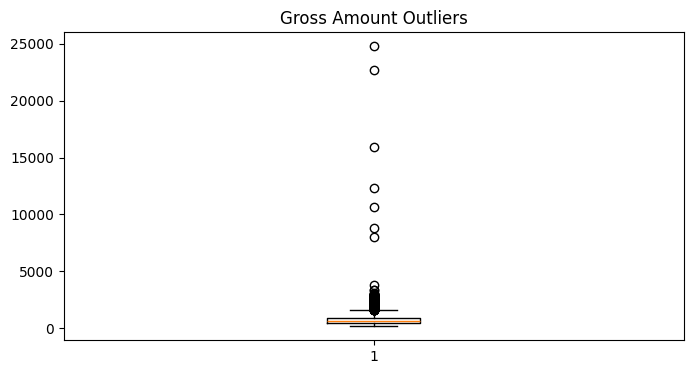

In [10]:
orders['gross_amount'].describe()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(orders['gross_amount'])
plt.title("Gross Amount Outliers")
plt.show()


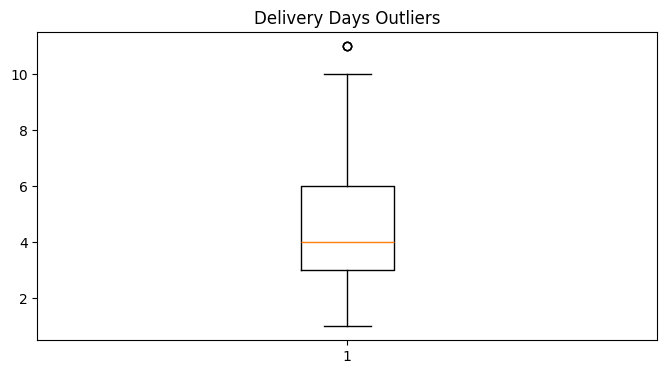

In [11]:
plt.figure(figsize=(8,4))
plt.boxplot(orders['delivery_days'])
plt.title("Delivery Days Outliers")
plt.show()


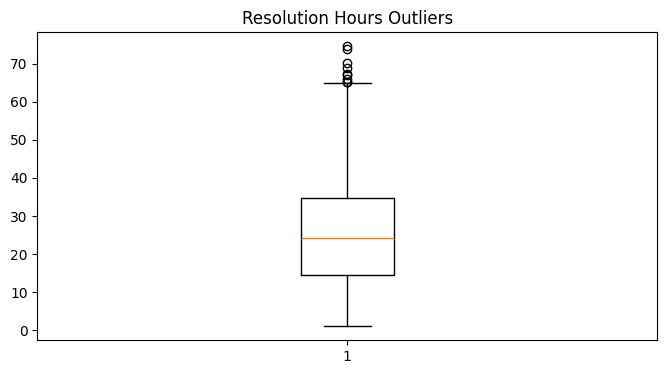

In [12]:
plt.figure(figsize=(8,4))
plt.boxplot(support['resolution_hours'])
plt.title("Resolution Hours Outliers")
plt.show()

## Outlier Analysis

Extreme values were detected in gross_amount.

These may represent:
- bulk purchases
- corporate orders
- data entry errors

Further business validation is recommended before removing them.

In [13]:
orders_missing = set(orders.customer_id) - set(customers.customer_id)

print("Customer IDs in Orders but not Customers:")
print(len(orders_missing))
support_missing = set(support.customer_id) - set(customers.customer_id)

print(len(support_missing))
web_missing = set(web.customer_id) - set(customers.customer_id)

print(len(web_missing))

Customer IDs in Orders but not Customers:
0
0
0


## Join Integrity

All datasets successfully join using customer_id.

No orphan customer records were detected.

The customer table can therefore be used as the primary entity table.

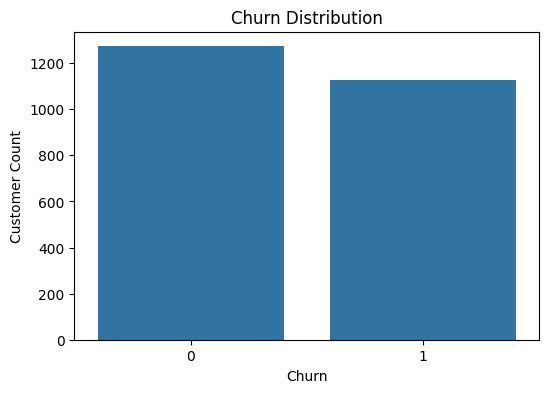

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=churn, x='churn_next_60d')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.show()

### Observation

This chart shows the distribution of churned and retained customers in the dataset.

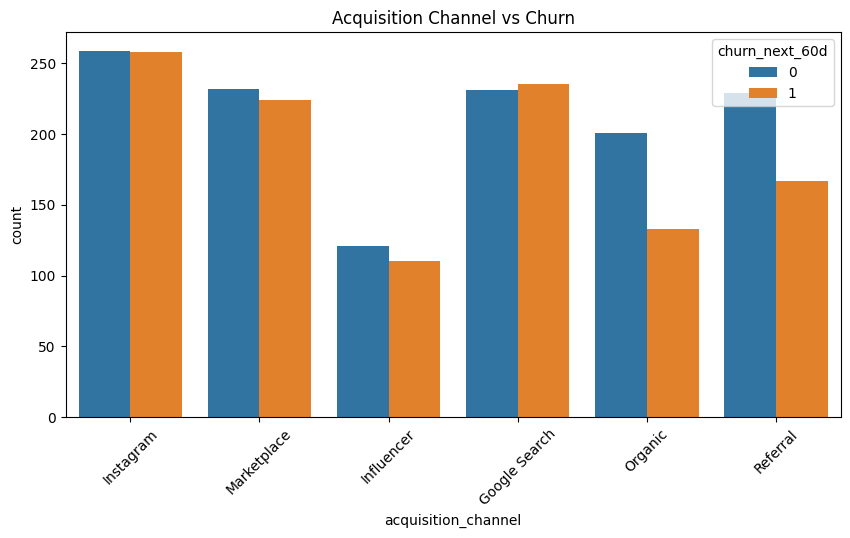

In [15]:
cust_churn = customers.merge(
    churn[['customer_id','churn_next_60d']],
    on='customer_id'
)
plt.figure(figsize=(10,5))
sns.countplot(
    data=cust_churn,
    x='acquisition_channel',
    hue='churn_next_60d'
)

plt.xticks(rotation=45)
plt.title("Acquisition Channel vs Churn")
plt.show()

### Observation

Different acquisition channels show different churn behaviour.

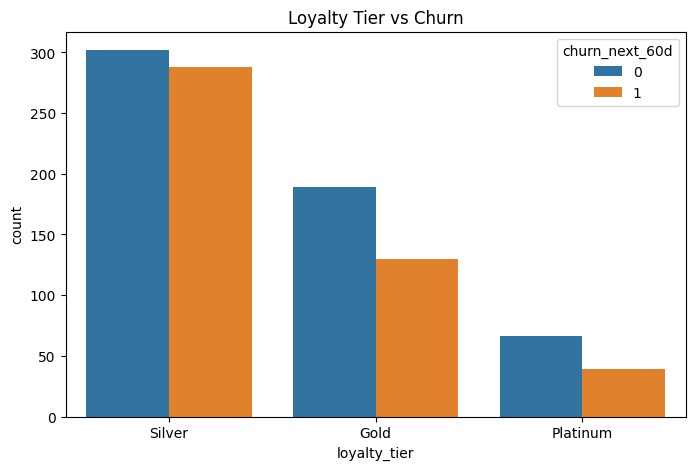

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=cust_churn,
    x='loyalty_tier',
    hue='churn_next_60d'
)

plt.title("Loyalty Tier vs Churn")
plt.show()

### Observation

Customers enrolled in loyalty programs appear to have different churn rates compared to non-enrolled customers.

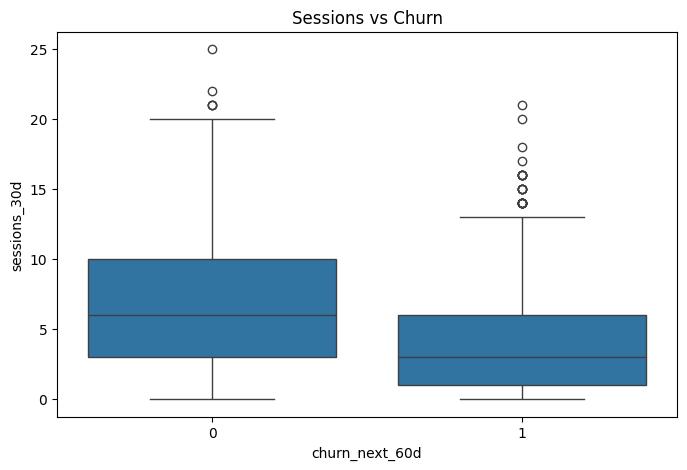

In [17]:
web_churn = web.merge(
    churn[['customer_id','churn_next_60d']],
    on='customer_id'
)
plt.figure(figsize=(8,5))

sns.boxplot(
    data=web_churn,
    x='churn_next_60d',
    y='sessions_30d'
)

plt.title("Sessions vs Churn")
plt.show()

### Observation

Website activity appears related to churn behaviour.

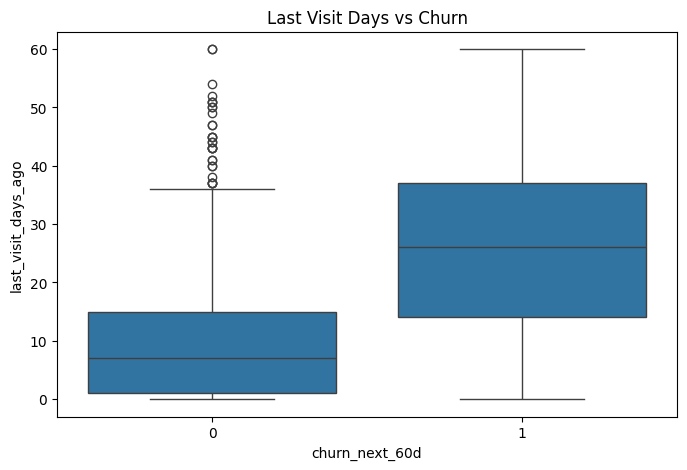

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=web_churn,
    x='churn_next_60d',
    y='last_visit_days_ago'
)

plt.title("Last Visit Days vs Churn")
plt.show()

### Observation

Customers who have not visited recently may be more likely to churn.

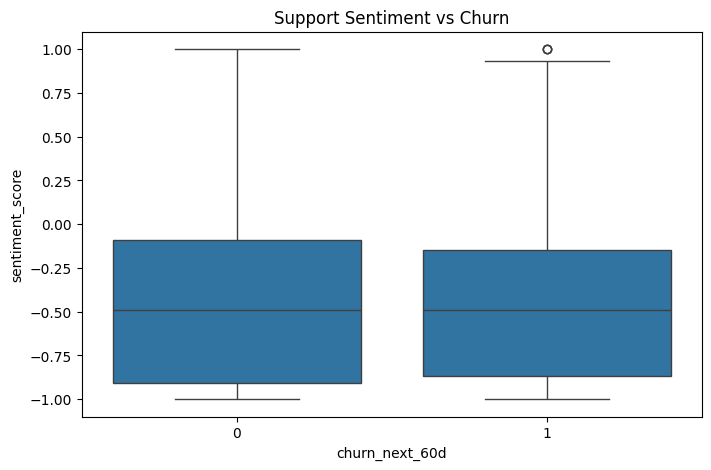

In [19]:
support_churn = support.merge(
    churn[['customer_id','churn_next_60d']],
    on='customer_id'
)
plt.figure(figsize=(8,5))

sns.boxplot(
    data=support_churn,
    x='churn_next_60d',
    y='sentiment_score'
)

plt.title("Support Sentiment vs Churn")
plt.show()

### Observation

Negative support experiences may contribute to customer churn.

***CHURN RISK HYPOTHESES***
### Hypothesis 1: Low Website Activity Increases Churn Risk

Evidence:
The Sessions vs Churn chart shows that customers with lower website activity tend to have higher churn rates.

Business Interpretation:
Customers who rarely interact with the platform are more likely to disengage and eventually stop purchasing.

### Hypothesis 2: Long Gaps Since Last Visit Increase Churn Risk

Evidence:
The Last Visit Days vs Churn chart indicates that churned customers generally have a higher number of days since their most recent visit.

Business Interpretation:
Customer inactivity is a strong early warning signal for potential churn.

### Hypothesis 3: Negative Support Experiences Increase Churn

Evidence:
The Support Sentiment vs Churn chart suggests that customers with lower sentiment scores are more likely to churn.

Business Interpretation:
Poor customer support experiences may reduce customer satisfaction and loyalty.

### Hypothesis 4: Loyalty Program Membership Reduces Churn

Evidence:
The Loyalty Tier vs Churn chart shows differences in churn behaviour between loyalty members and non-members.

Business Interpretation:
Customers enrolled in loyalty programmes may feel more connected to the brand and are therefore less likely to leave.

### Hypothesis 5: Acquisition Channel Influences Churn Behaviour

Evidence:
The Acquisition Channel vs Churn chart demonstrates variation in churn rates across acquisition channels.

Business Interpretation:
Some acquisition channels may attract higher-quality customers than others.



CONCLUSION

The analysis identified several behavioural and operational factors associated with customer churn.

Key findings include:

1. Lower website engagement is associated with increased churn.
2. Customers who have not visited recently are more likely to churn.
3. Negative support experiences correlate with higher churn.
4. Loyalty programme participation appears to improve retention.
5. Customer acquisition source influences long-term retention.

These findings can help guide retention campaigns and future churn prediction models.